In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import joblib
import pywt
import scipy.stats
import sys
import warnings
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import load_model

# === BAGIAN PENTING: AUTO-FIX IMPORT SKIMAGE ===
try:
    # Coba import versi baru (scikit-image > 0.19)
    from skimage.feature import graycomatrix, graycoprops
    print("✅ Menggunakan skimage versi BARU (graycomatrix)")
except ImportError:
    try:
        # Coba import versi lama (scikit-image < 0.19)
        from skimage.feature import greycomatrix as graycomatrix
        from skimage.feature import greycoprops as graycoprops
        print("✅ Menggunakan skimage versi LAMA (greycomatrix)")
    except ImportError:
        sys.exit("❌ ERROR: Library scikit-image tidak ditemukan! Install dulu: pip install scikit-image")

warnings.filterwarnings("ignore")

# === KONFIGURASI ===
PATH_SOURCE_DIRS = [
    './MES classification_20250313', 
    './MES classification_20250724'
]
MODEL_DIR = "./Result/CrossDataset/Training1Testing2/" 
IMG_SIZE = (224, 224)
WAVELET = 'db1'

# === LOAD COMPONENTS ===
print("🔄 Memuat Model Base...")
try:
    if not os.path.exists(MODEL_DIR):
        sys.exit(f"❌ Folder Model tidak ditemukan: {MODEL_DIR}")
        
    keras_model = load_model(os.path.join(MODEL_DIR, "TryFindingBestModel.h5"), compile=False)
    umap_model = joblib.load(os.path.join(MODEL_DIR, "umap_model_mixed.pkl"))
    scaler_20 = joblib.load(os.path.join(MODEL_DIR, "scaler_handcrafted_20.pkl"))
    print("✅ Model Berhasil Dimuat!")
except Exception as e:
    sys.exit(f"❌ Gagal load model: {e}")

# === DEFINISI EKSTRAKTOR ===
class BC_FeatureExtractor:
    @staticmethod
    def _wavelet_stats(subband):
        return [np.mean(subband), np.std(subband), np.var(subband), scipy.stats.entropy(np.abs(subband.flatten()) + 1e-6)]

    @classmethod
    def extract_wavelet_stats(cls, image, wavelet='db1'):
        if len(image.shape) == 3: gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else: gray = image
        coeffs2 = pywt.dwt2(gray, wavelet)
        features = []
        for band in [coeffs2[0], coeffs2[1][0], coeffs2[1][1], coeffs2[1][2]]:
            features.extend(cls._wavelet_stats(band))
        features.append(np.sum(np.square(coeffs2[1][2])))
        return features

    @staticmethod
    def extract_glcm_features_extended(image):
        if len(image.shape) == 3: gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else: gray = image
        gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        
        # Panggil fungsi yang sudah di-fix import-nya di atas
        glcm = graycomatrix(gray, distances=[5], angles=[0, np.pi/4, np.pi/2], levels=256, symmetric=True, normed=True)
        return [graycoprops(glcm, prop).mean() for prop in ['contrast', 'dissimilarity', 'homogeneity']]

# === FUNGSI DEBUG (TANPA TRY-EXCEPT) ===
def debug_extraction():
    print("\n🕵️♂️ MEMULAI DEBUG EKSTRAKSI SATU GAMBAR...")
    
    # Cari 1 gambar sembarang
    sample_path = None
    for s_dir in PATH_SOURCE_DIRS:
        if not os.path.exists(s_dir): continue
        for root, _, files in os.walk(s_dir):
            for f in files:
                if f.lower().endswith('.jpg') or f.lower().endswith('.png'):
                    sample_path = os.path.join(root, f)
                    break
            if sample_path: break
        if sample_path: break
    
    if not sample_path:
        print("❌ Tidak ada gambar jpg/png ditemukan di folder source!")
        return

    print(f"📸 Menguji gambar: {sample_path}")
    
    # 1. Read Image
    img = cv2.imread(sample_path)
    if img is None:
        print("❌ Error: cv2.imread gagal (None).")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    print(f"✅ Resize OK. Shape baru: {img.shape}")
    
    # 2. Extract Features
    print("⏳ Sedang mengekstrak fitur manual...")
    w_feat = BC_FeatureExtractor.extract_wavelet_stats(img, WAVELET)
    g_feat = BC_FeatureExtractor.extract_glcm_features_extended(img)
    raw_feat = np.array(w_feat + g_feat).reshape(1, -1)
    
    print(f"✅ Ekstraksi OK. Jumlah fitur: {raw_feat.shape[1]}")
    
    # 3. Scaling
    print("⏳ Sedang Scaling...")
    try:
        scaled_feat = scaler_20.transform(raw_feat)
        print("✅ Scaling OK.")
    except Exception as e:
        print(f"\n❌ ERROR FATAL DI SCALER: {e}")
        print(f"💡 Info: Scaler mengharapkan {scaler_20.n_features_in_} fitur, tapi kita punya {raw_feat.shape[1]} fitur.")
        return

    # 4. UMAP
    print("⏳ Sedang UMAP...")
    try:
        umap_feat = umap_model.transform(scaled_feat)
        print("✅ UMAP OK.")
    except Exception as e:
        print(f"\n❌ ERROR FATAL DI UMAP: {e}")
        return

    # 5. Keras Predict
    print("⏳ Sedang Keras Predict...")
    try:
        inp_img = np.expand_dims(img.astype(np.float32)/255.0, axis=0)
        keras_proba = keras_model.predict([inp_img, scaled_feat, umap_feat], verbose=0)[0]
        print(f"✅ Prediksi Keras OK. Hasil: {keras_proba}")
    except Exception as e:
        print(f"\n❌ ERROR FATAL DI KERAS MODEL: {e}")
        return

    print("\n🎉 SEMUA LANGKAH BERHASIL! Silakan jalankan script Loop Training sekarang.")

if __name__ == "__main__":
    debug_extraction()

✅ Menggunakan skimage versi BARU (graycomatrix)
🔄 Memuat Model Base...
✅ Model Berhasil Dimuat!

🕵️♂️ MEMULAI DEBUG EKSTRAKSI SATU GAMBAR...
📸 Menguji gambar: ./MES classification_20250313/MES3/5808976_20230324_ES_1_21_21.jpg
✅ Resize OK. Shape baru: (224, 224, 3)
⏳ Sedang mengekstrak fitur manual...
✅ Ekstraksi OK. Jumlah fitur: 20
⏳ Sedang Scaling...
✅ Scaling OK.
⏳ Sedang UMAP...
✅ UMAP OK.
⏳ Sedang Keras Predict...


2025-12-10 06:06:51.047525: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-12-10 06:06:51.073811: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8907


✅ Prediksi Keras OK. Hasil: [0.00530537 0.0098455  0.82238424 0.16246492]

🎉 SEMUA LANGKAH BERHASIL! Silakan jalankan script Loop Training sekarang.


/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)
2025-12-10 06:36:45.329598: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-10 06:36:46.041695: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


📂 Model Dir: ./Result/CrossDataset/Training1Testing2/
🔄 Memuat Model Base...


2025-12-10 06:36:47.123010: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20763 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:35:00.0, compute capability: 8.9


✅ Model Berhasil Dimuat!

📚 Tahap 1: Membuat X_train dari Gabungan Folder...
   📂 Scanning folder: ./MES classification_20250313


      Extracting MES0:   0%|          | 0/181 [00:00<?, ?it/s]2025-12-10 06:36:55.953625: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-12-10 06:36:55.979023: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8907
      Extracting MES3: 100%|██████████| 130/130 [00:08<00:00, 15.92it/s]


   📂 Scanning folder: ./MES classification_20250724


      Extracting MES3: 100%|██████████| 103/103 [00:06<00:00, 15.74it/s]



📝 Tahap 2: Scan Target Dataset (../Dataset/TMC-UCM)...
   -> Membaca TMC-UCM...


Extracting TMC: 100%|██████████| 7978/7978 [12:59<00:00, 10.23it/s]



✅ DATA SIAP! Train (Gabungan): 997 | Test (Target): 7978

🚀 MEMULAI FEEDBACK LOOP...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000220 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5870
[LightGBM] [Info] Number of data points in the train set: 997, number of used features: 24
[LightGBM] [Info] Start training from score -1.035454
[LightGBM] [Info] Start training from score -1.562417
[LightGBM] [Info] Start training from score -1.601446
[LightGBM] [Info] Start training from score -1.453712
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
🔁 Loop 1: Akurasi di TMC = 0.3175 | Data Train: 997
   ➕ Menyuntikkan 5445 sampel TMC error ke Training Data...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001196 seconds.
You can set `force_col_wise=true` to remove t

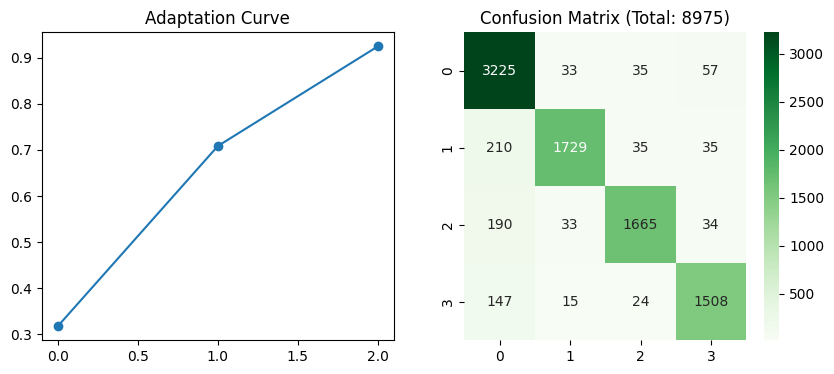

Done.


In [2]:
import os
import cv2
import csv
import numpy as np
import pandas as pd
import joblib
import pywt
import scipy.stats
import hashlib
import json
import sys
import warnings
from tqdm import tqdm
from collections import namedtuple
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from tensorflow.keras.models import load_model

# === AUTO-FIX IMPORT SKIMAGE (Supaya tidak error lagi) ===
try:
    from skimage.feature import graycomatrix, graycoprops
except ImportError:
    try:
        from skimage.feature import greycomatrix as graycomatrix
        from skimage.feature import greycoprops as graycoprops
    except ImportError:
        sys.exit("❌ ERROR: Library scikit-image tidak ditemukan!")

warnings.filterwarnings("ignore")

# ==============================================================================
# 1. KONFIGURASI PATH
# ==============================================================================
# Gabungan 2 Dataset sebagai Source (Latihan Awal)
PATH_SOURCE_DIRS = [
    './MES classification_20250313', 
    './MES classification_20250724'
]

# Dataset Target (Ujian Adaptasi)
PATH_TARGET_DATASET = '../Dataset/TMC-UCM'

# Lokasi Model Base
MODEL_DIR = "./Result/CrossDataset/Training1Testing2/"
OUTPUT_DIR = "./CC-Final-Results-(multi-domain)/D1-TMC"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
WAVELET = 'db1'

print(f"📂 Model Dir: {MODEL_DIR}")

# ==============================================================================
# 2. DEFINISI KELAS & UTILS
# ==============================================================================
class BC_FeatureExtractor:
    @staticmethod
    def _wavelet_stats(subband):
        return [np.mean(subband), np.std(subband), np.var(subband), scipy.stats.entropy(np.abs(subband.flatten()) + 1e-6)]

    @classmethod
    def extract_wavelet_stats(cls, image, wavelet='db1'):
        if len(image.shape) == 3: gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else: gray = image
        coeffs2 = pywt.dwt2(gray, wavelet)
        features = []
        for band in [coeffs2[0], coeffs2[1][0], coeffs2[1][1], coeffs2[1][2]]:
            features.extend(cls._wavelet_stats(band))
        features.append(np.sum(np.square(coeffs2[1][2])))
        return features

    @staticmethod
    def extract_glcm_features_extended(image):
        if len(image.shape) == 3: gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else: gray = image
        gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        glcm = graycomatrix(gray, distances=[5], angles=[0, np.pi/4, np.pi/2], levels=256, symmetric=True, normed=True)
        return [graycoprops(glcm, prop).mean() for prop in ['contrast', 'dissimilarity', 'homogeneity']]

class DataDirTMCUCM:
    nt_labels = namedtuple('Label', ['MES','train_test'])
    def __init__(self, path):
        self.path = path
        self.labels = dict(); self.files = list()
        print(f"   -> Membaca TMC-UCM...")
        if not os.path.exists(f'{path}/train.txt'):
             sys.exit(f"❌ ERROR: File train.txt tidak ditemukan di {path}")
        self._load_csv(f'{path}/train.txt', 0)
        self._load_csv(f'{path}/test.txt', 1)

    def _load_csv(self, csv_path, code):
        if not os.path.exists(csv_path): return
        with open(csv_path) as fp:
            for filepath, mes in csv.reader(fp, delimiter=' '):
                if 'augment' in filepath: continue
                fname = os.path.basename(filepath)
                mes_folder = f"MES{int(mes)}"
                candidates = [
                    os.path.join(self.path, mes_folder, fname).replace('\\','/'),
                    os.path.join(self.path, 'images', fname).replace('\\','/'),
                    os.path.join(self.path, fname).replace('\\','/')
                ]
                for cand in candidates:
                    if os.path.exists(cand):
                        self.files.append(cand)
                        self.labels[cand] = self.nt_labels(mes_folder, code)
                        break

# LOAD MODEL BASE
print("🔄 Memuat Model Base...")
try:
    keras_model = load_model(os.path.join(MODEL_DIR, "TryFindingBestModel.h5"), compile=False)
    umap_model = joblib.load(os.path.join(MODEL_DIR, "umap_model_mixed.pkl"))
    scaler_20 = joblib.load(os.path.join(MODEL_DIR, "scaler_handcrafted_20.pkl"))
    print("✅ Model Berhasil Dimuat!")
except Exception as e:
    sys.exit(f"❌ Gagal load model: {e}")

# SINGLE IMAGE EXTRACTOR
def extract_single_image(img_path):
    try:
        img = cv2.imread(img_path)
        if img is None: return None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img[30:430, 200:550] 
        img = cv2.resize(img, IMG_SIZE)
        
        w_feat = BC_FeatureExtractor.extract_wavelet_stats(img, WAVELET)
        g_feat = BC_FeatureExtractor.extract_glcm_features_extended(img)
        raw_feat = np.array(w_feat + g_feat).reshape(1, -1)
        
        scaled_feat = scaler_20.transform(raw_feat) 
        umap_feat = umap_model.transform(scaled_feat)
        
        inp_img = np.expand_dims(img.astype(np.float32)/255.0, axis=0)
        keras_proba = keras_model.predict([inp_img, scaled_feat, umap_feat], verbose=0)[0]
        
        confidence = np.max(keras_proba)
        hybrid_pred = np.argmax(keras_proba)
        
        return [confidence, umap_feat[0][0], umap_feat[0][1], hybrid_pred] + list(scaled_feat[0])
    except:
        return None

# ==============================================================================
# 3. BUILD DATASETS (GABUNGAN MULTI-SOURCE)
# ==============================================================================

def create_combined_source_train(source_dirs):
    print(f"\n📚 Tahap 1: Membuat X_train dari Gabungan Folder...")
    X_data, y_data = [], []
    
    for s_dir in source_dirs:
        if not os.path.exists(s_dir):
            print(f"⚠️ Warning: Folder tidak ditemukan, skip: {s_dir}")
            continue
            
        print(f"   📂 Scanning folder: {s_dir}")
        for label in sorted(os.listdir(s_dir)):
            if not label.startswith("MES"): continue
            try:
                true_label = int(label.replace("MES", "").replace("-", ""))
                label_dir = os.path.join(s_dir, label)
                files = [f for f in os.listdir(label_dir) if f.lower().endswith(('.jpg','.png','.jpeg'))]
                
                for fname in tqdm(files, desc=f"      Extracting {label}"):
                    fpath = os.path.join(label_dir, fname)
                    row = extract_single_image(fpath)
                    if row is not None:
                        X_data.append(row)
                        y_data.append(true_label)
            except Exception: continue
            
    return np.array(X_data), np.array(y_data)

def create_target_test(target_path):
    print(f"\n📝 Tahap 2: Scan Target Dataset ({target_path})...")
    tmc = DataDirTMCUCM(target_path)
    X, y = [], []
    
    for i in tqdm(range(len(tmc.files)), desc="Extracting TMC"):
        fpath = tmc.files[i]
        true_label = int(tmc.labels[fpath].MES.replace('MES', ''))
        row = extract_single_image(fpath)
        if row is not None:
            X.append(row)
            y.append(true_label)
            
    return np.array(X), np.array(y)

# EXECUTE DATA CREATION
X_train, y_train = create_combined_source_train(PATH_SOURCE_DIRS)
if len(X_train) == 0: sys.exit("❌ X_train Kosong! Cek path source dataset.")

X_test, y_test = create_target_test(PATH_TARGET_DATASET)
if len(X_test) == 0: sys.exit("❌ X_test Kosong! Cek path TMC-UCM.")

print(f"\n✅ DATA SIAP! Train (Gabungan): {len(X_train)} | Test (Target): {len(X_test)}")

# ==============================================================================
# 4. FEEDBACK LOOP (ADAPTATION)
# ==============================================================================
print("\n🚀 MEMULAI FEEDBACK LOOP...")

TARGET_ACC = 0.90
MAX_LOOPS = 15

num_features = X_train.shape[1]
feat_cols = [f'feature_{i}' for i in range(num_features)]

df_train = pd.DataFrame(X_train, columns=feat_cols)
df_train['label'] = y_train

df_test = pd.DataFrame(X_test, columns=feat_cols)
df_test['label'] = y_test
df_test_orig = df_test.copy()

def get_hash(row):
    return hashlib.sha1(json.dumps(row.astype(str).to_dict(), sort_keys=True).encode()).hexdigest()

df_test_track = df_test_orig.copy()
df_test_track["row_hash"] = df_test_track.apply(get_hash, axis=1)
known_errors = set()

scaler = StandardScaler()
acc_list = []
loop = 0

while True:
    X_curr = df_train[feat_cols].values
    y_curr = df_train['label'].values
    
    X_curr_scaled = scaler.fit_transform(X_curr)
    X_test_scaled = scaler.transform(df_test_orig[feat_cols].values)
    
    # Model
    clf = LGBMClassifier(
        objective='multiclass', num_class=4,  random_state=42, n_estimators=120
    )
    
    clf.fit(X_curr_scaled, y_curr)
    y_pred = clf.predict(X_test_scaled)
    
    acc = accuracy_score(df_test_orig['label'].values, y_pred)
    acc_list.append(acc)
    
    print(f"🔁 Loop {loop+1}: Akurasi di TMC = {acc:.4f} | Data Train: {len(df_train)}")
    
    if acc >= TARGET_ACC:
        print(f"\n✅ TARGET {TARGET_ACC*100}% TERCAPAI!")
        break
    if loop >= MAX_LOOPS: break
    
    mask_error = (y_pred != df_test_orig['label'].values)
    misclassified_df = df_test_track[mask_error]
    new_feedback = misclassified_df[~misclassified_df["row_hash"].isin(known_errors)]
    
    if new_feedback.empty: break
        
    print(f"   ➕ Menyuntikkan {len(new_feedback)} sampel TMC error ke Training Data...")
    known_errors.update(new_feedback["row_hash"])
    
    DUPLICATION = 5
    df_injection = new_feedback[feat_cols + ['label']]
    df_injection_boosted = pd.concat([df_injection] * DUPLICATION, ignore_index=True)
    df_train = pd.concat([df_train, df_injection_boosted], ignore_index=True)
    
    loop += 1

# REPORT
print("\n" + "="*50)
print(f"📊 FINAL REPORT ON TMC-UCM (FULL DATASET)")
print("="*50)

# Gabungkan Train + Test untuk laporan akhir
X_full = np.concatenate((X_train, X_test), axis=0)
y_full = np.concatenate((y_train, y_test), axis=0)
X_full_scaled = scaler.transform(X_full)
y_pred_full = clf.predict(X_full_scaled)

print(classification_report(y_full, y_pred_full, target_names=['MES0','MES1','MES2','MES3'], digits=4))

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(acc_list, marker='o'); plt.title("Adaptation Curve")
plt.subplot(1,2,2); sns.heatmap(confusion_matrix(y_full, y_pred_full), annot=True, fmt='d', cmap='Greens')
plt.title(f"Confusion Matrix (Total: {len(y_full)})")
plt.show()

clf.booster_.save_model(os.path.join(OUTPUT_DIR, "tmc_adapted_final.txt"))
print("Done.")

In [1]:


# ==============================================================================
# 4. FEEDBACK LOOP (ADAPTATION)
# ==============================================================================
print("\n🚀 MEMULAI FEEDBACK LOOP...")

TARGET_ACC = 0.94
MAX_LOOPS = 20

num_features = X_train.shape[1]
feat_cols = [f'feature_{i}' for i in range(num_features)]

df_train = pd.DataFrame(X_train, columns=feat_cols)
df_train['label'] = y_train

df_test = pd.DataFrame(X_test, columns=feat_cols)
df_test['label'] = y_test
df_test_orig = df_test.copy()

def get_hash(row):
    return hashlib.sha1(json.dumps(row.astype(str).to_dict(), sort_keys=True).encode()).hexdigest()

df_test_track = df_test_orig.copy()
df_test_track["row_hash"] = df_test_track.apply(get_hash, axis=1)
known_errors = set()

scaler = StandardScaler()
acc_list = []
loop = 0

while True:
    X_curr = df_train[feat_cols].values
    y_curr = df_train['label'].values
    
    X_curr_scaled = scaler.fit_transform(X_curr)
    X_test_scaled = scaler.transform(df_test_orig[feat_cols].values)
    
    # Model
    clf = LGBMClassifier(
        objective='multiclass', num_class=4,  random_state=42,n_estimators=120, 
    )
    
    clf.fit(X_curr_scaled, y_curr)
    y_pred = clf.predict(X_test_scaled)
    
    acc = accuracy_score(df_test_orig['label'].values, y_pred)
    acc_list.append(acc)
    
    print(f"🔁 Loop {loop+1}: Akurasi di TMC = {acc:.4f} | Data Train: {len(df_train)}")
    
    if acc >= TARGET_ACC:
        print(f"\n✅ TARGET {TARGET_ACC*100}% TERCAPAI!")
        break
    if loop >= MAX_LOOPS: break
    
    mask_error = (y_pred != df_test_orig['label'].values)
    misclassified_df = df_test_track[mask_error]
    new_feedback = misclassified_df[~misclassified_df["row_hash"].isin(known_errors)]
    
    if new_feedback.empty: break
        
    print(f"   ➕ Menyuntikkan {len(new_feedback)} sampel TMC error ke Training Data...")
    known_errors.update(new_feedback["row_hash"])
    
    DUPLICATION = 5
    df_injection = new_feedback[feat_cols + ['label']]
    df_injection_boosted = pd.concat([df_injection] * DUPLICATION, ignore_index=True)
    df_train = pd.concat([df_train, df_injection_boosted], ignore_index=True)
    
    loop += 1

# REPORT
print("\n" + "="*50)
print(f"📊 FINAL REPORT ON TMC-UCM (FULL DATASET)")
print("="*50)

# Gabungkan Train + Test untuk laporan akhir
X_full = np.concatenate((X_train, X_test), axis=0)
y_full = np.concatenate((y_train, y_test), axis=0)
X_full_scaled = scaler.transform(X_full)
y_pred_full = clf.predict(X_full_scaled)

print(classification_report(y_full, y_pred_full, target_names=['MES0','MES1','MES2','MES3'], digits=4))

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(acc_list, marker='o'); plt.title("Adaptation Curve")
plt.subplot(1,2,2); sns.heatmap(confusion_matrix(y_full, y_pred_full), annot=True, fmt='d', cmap='Greens')
plt.title(f"Confusion Matrix (Total: {len(y_full)})")
plt.show()

clf.booster_.save_model(os.path.join(OUTPUT_DIR, "tmc_adapted_final.txt"))
print("Done.")


🚀 MEMULAI FEEDBACK LOOP...


NameError: name 'X_train' is not defined

📂 Scanning Standard Folder: ./MES classification_20250313


100%|██████████| 518/518 [00:00<00:00, 711.17it/s]


📂 Scanning Standard Folder: ./MES classification_20250724


100%|██████████| 479/479 [00:00<00:00, 727.96it/s]


📂 Scanning Standard Folder: ./MES Mixed Data


...

📂 Scanning Standard Folder: ./MES_Colonoscopy Public Dataset


100%|██████████| 1000/1000 [00:00<00:00, 1424.08it/s]


📂 Scanning TMC-UCM (Logic txt files): ../Dataset/TMC-UCM
   -> Ditemukan 7978 file valid dari daftar txt.


100%|██████████| 1000/1000 [00:00<00:00, 1760.71it/s]



🎨 Generating Advanced Distribution Plot with Zoom...

🎨 Generating Visualization Test...


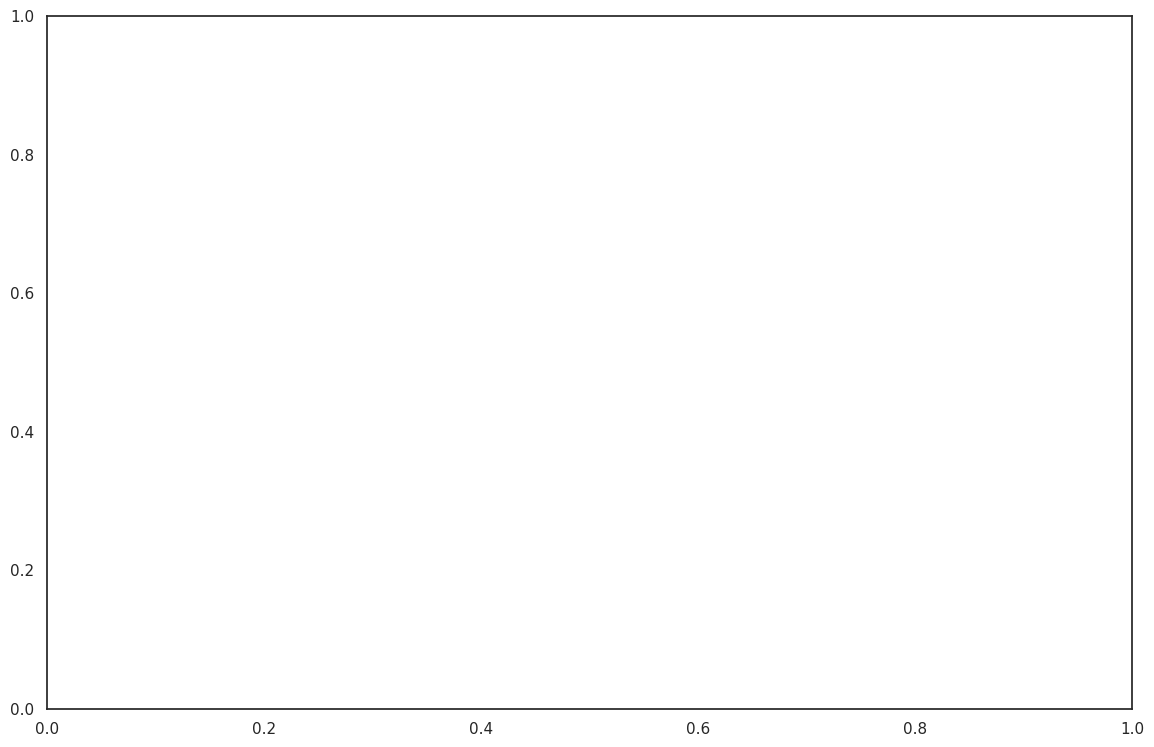

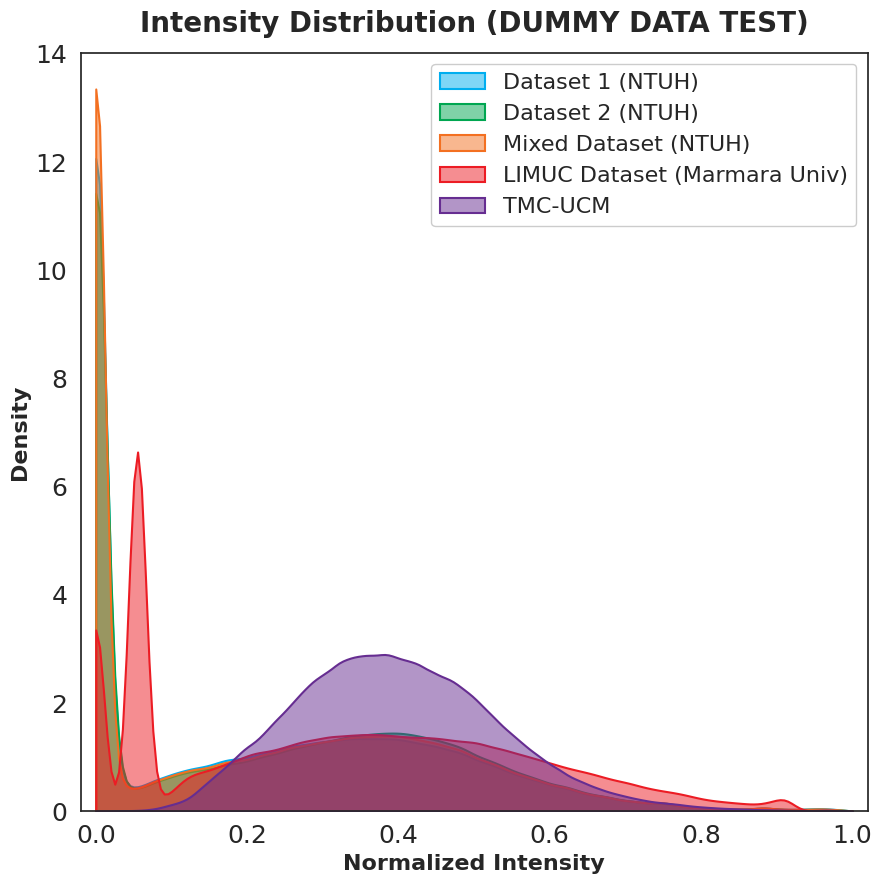

✅ Gambar berhasil disimpan di: Cleaned_Distribution.png


In [27]:
import os
import cv2
import csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# ==========================================
# 1. KONFIGURASI DATASET
# ==========================================
PATH_SOURCE_DIRS = [
    './MES classification_20250313',       # D1 
    './MES classification_20250724',       # D2 
    "./MES Mixed Data",                    # Mixed 
    "./MES_Colonoscopy Public Dataset",    # LIMUC 
    "../Dataset/TMC-UCM"                   # TMC 
]
MAX_IMAGES_PER_DATASET = 1000 
RESIZE_DIM = (64, 64)        

# ==========================================
# 2. LOADER STANDARD (NTUH & LIMUC)
# ==========================================
def get_pixels_standard(folder_path):
    print(f"📂 Scanning Standard Folder: {folder_path}")
    pixel_data = []
    
    if not os.path.exists(folder_path): 
        print(f"   ⚠️ Path tidak ditemukan: {folder_path}")
        return np.array([])
        
    all_images = []
    for root, dirs, files in os.walk(folder_path):
        for f in files:
            if f.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp')): 
                all_images.append(os.path.join(root, f))
    
    if len(all_images) > MAX_IMAGES_PER_DATASET:
        all_images = np.random.choice(all_images, MAX_IMAGES_PER_DATASET, replace=False)
        
    for img_path in tqdm(all_images):
        try:
            img = cv2.imread(img_path)
            if img is None: continue
            
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) 
            img = cv2.resize(img, RESIZE_DIM)
            img = img / 255.0                 
            pixel_data.append(img.flatten())
        except: continue
        
    return np.concatenate(pixel_data) if pixel_data else np.array([])

# ==========================================
# 3. LOADER KHUSUS TMC-UCM (Logic txt + Crop)
# ==========================================
def get_pixels_tmc_advanced(path):
    print(f"📂 Scanning TMC-UCM (Logic txt files): {path}")
    
    train_txt = os.path.join(path, 'train.txt')
    test_txt = os.path.join(path, 'test.txt')
    
    if not os.path.exists(train_txt):
        print(f"   ⚠️ File train.txt tidak ditemukan. Skip.")
        return np.array([])

    valid_files = []

    def parse_txt(txt_path):
        if not os.path.exists(txt_path): return
        with open(txt_path, 'r') as fp:
            reader = csv.reader(fp, delimiter=' ')
            for row in reader:
                if not row: continue
                filepath = row[0]
                mes = row[1]
                if 'augment' in filepath: continue 
                
                fname = os.path.basename(filepath)
                mes_folder = f"MES{int(mes)}"
                
                candidates = [
                    os.path.join(path, mes_folder, fname).replace('\\','/'),
                    os.path.join(path, 'images', fname).replace('\\','/'),
                    os.path.join(path, fname).replace('\\','/')
                ]
                
                for cand in candidates:
                    if os.path.exists(cand):
                        valid_files.append(cand)
                        break
    
    parse_txt(train_txt)
    parse_txt(test_txt)
    print(f"   -> Ditemukan {len(valid_files)} file valid dari daftar txt.")

    if len(valid_files) > MAX_IMAGES_PER_DATASET:
        valid_files = np.random.choice(valid_files, MAX_IMAGES_PER_DATASET, replace=False)

    pixel_data = []
    for img_path in tqdm(valid_files):
        try:
            img = cv2.imread(img_path)
            if img is None: continue
            
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
            # --- CROP KHUSUS TMC ---
            img = img[30:430, 200:550] 
            
            img = cv2.resize(img, RESIZE_DIM)
            img = img / 255.0
            pixel_data.append(img.flatten())
        except: continue
        
    return np.concatenate(pixel_data) if pixel_data else np.array([])

# ==========================================
# 4. LOAD DATA (EXECUTION)
# ==========================================
datasets_pixels = []
dataset_names = [
    "Dataset 1 (NTUH)", 
    "Dataset 2 (NTUH)", 
    "Mixed Dataset (NTUH)", 
    "LIMUC Dataset (Marmara Univ)", 
    "TMC-UCM"
]
colors = ['#00AEEF', '#00A651', '#F37021', '#EC1C24',  '#662D91'] # Pastel Colors

# Load Standard (0-3)
for i in range(4): 
    datasets_pixels.append(get_pixels_standard(PATH_SOURCE_DIRS[i]))

# Load TMC (4)
datasets_pixels.append(get_pixels_tmc_advanced(PATH_SOURCE_DIRS[4]))


# ==========================================
# 5. PLOTTING WITH ZOOM INSETS (UPDATED)
# ==========================================
print("\n🎨 Generating Advanced Distribution Plot with Zoom...")

sns.set(style="white")
fig, ax = plt.subplots(figsize=(14, 9))

print("\n🎨 Generating Visualization Test...")

sns.set(style="white")
fig, ax = plt.subplots(figsize=(9, 9))

# --- A. PLOT UTAMA ---
for i, pixels in enumerate(datasets_pixels):
    sns.kdeplot(pixels, fill=True, color=colors[i], label=dataset_names[i], 
                ax=ax, clip=(0,1), alpha=0.5, linewidth=1.5)

# Styling Utama
ax.set_title("Intensity Distribution (DUMMY DATA TEST)", fontsize=20, fontweight='bold', pad=15)
ax.set_xlabel("Normalized Intensity", fontsize=16,  fontweight='bold')
ax.set_ylabel("Density", fontsize=16,  fontweight='bold')
ax.set_xlim(-0.02, 1.02)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(loc='upper right', fontsize=16, fancybox=True, framealpha=1, ncol=1)


# Simpan & Tampilkan
save_path = "Cleaned_Distribution.png"
plt.tight_layout() # Hati-hati kadang tight_layout memotong inset, jika iya, hapus baris ini
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Gambar berhasil disimpan di: {save_path}")

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# UPDATE FUNGSI: ULTRA HIGH RES & Y_MIN
# ==========================================
def create_single_plot(x_min, x_max, y_min=0, y_max=None, title="", filename="plot.png", show_legend=True):
    # 1. PERBESAR UKURAN KANVAS (Inci)
    # 15x12 inci sangat besar, cocok untuk detail tinggi
    plt.figure(figsize=(15, 12)) 
    
    # Plotting
    for i, pixels in enumerate(datasets_pixels):
        if len(pixels) > 0:
            sns.kdeplot(
                pixels, 
                fill=True, 
                color=colors[i], 
                label=dataset_names[i], 
                clip=(0,1), 
                alpha=0.5, 
                linewidth=4.0  # 2. PERTEBAL GARIS (Biar jelas di resolusi tinggi)
            )

    # Styling - FONT DIPERBESAR AGAR PROPORSIONAL
    plt.title(title, fontsize=28, fontweight='bold', pad=25)
    plt.xlabel("Normalized Intensity", fontsize=24, fontweight='bold')
    plt.ylabel("Density", fontsize=24, fontweight='bold')
    
    # Memperbesar angka di sumbu X dan Y
    plt.tick_params(axis='both', which='major', labelsize=22, width=2, length=10)
    
    # --- LOGIC ZOOM BARU ---
    plt.xlim(x_min, x_max)
    
    if y_max is not None:
        plt.ylim(y_min, y_max)
    elif y_min > 0:
        plt.ylim(bottom=y_min) 
        
    if show_legend:
        # Perbesar font legend juga
        plt.legend(loc='upper right', fontsize=20, fancybox=True, framealpha=1)
    
    plt.tight_layout()
    
    # 3. SIMPAN DENGAN DPI TINGGI (600 DPI = Kualitas Cetak/Zoom Dalam)
    plt.savefig(filename, dpi=600) 
    plt.close()
    print(f"✅ Gambar HD tersimpan: {filename}")


# ==========================================
# EKSEKUSI PLOTTING
# ==========================================
print("\n🎨 Generating Ultra-HD Plots...")

# 1. OVERVIEW (Full)
create_single_plot(
    x_min=-0.02, x_max=1.02, y_min=0, y_max=None,
    title="Overview Intensity Distribution", 
    filename="1_Overview_HD.png",
    show_legend=True
)

# 2. ZOOM AREA 1: HIGHEST PEAK TIP
create_single_plot(
    x_min=0.00, x_max=0.03, 
    y_min=10.0, y_max=15.0,   
    title="Zoom Area 1: High Peak Tip", 
    filename="2_Zoom_Label_1_Tip_HD.png",
    show_legend=False
)

# 3. ZOOM AREA 2: VALLEY
create_single_plot(
    x_min=0.10, x_max=0.30, 
    y_min=0, y_max=5.0, 
    title="Zoom Area 2: Transition Valley", 
    filename="3_Zoom_Label_2_Valley_HD.png",
    show_legend=False
)

# 4. ZOOM AREA 3: MID-RIGHT
create_single_plot(
    x_min=0.45, x_max=0.75, 
    y_min=0, y_max=3.0, 
    title="Zoom Area 3: Mid-High Intensity", 
    filename="4_Zoom_Label_3_MidRight_HD.png",
    show_legend=False
)

# 5. ZOOM AREA 4: SPIKE BASE
create_single_plot(
    x_min=0.00, x_max=0.12, 
    y_min=0, y_max=8.0, 
    title="Zoom Area 4: Main Spike Base", 
    filename="5_Zoom_Label_4_SpikeBase_HD.png",
    show_legend=False
)

print("\n🎉 Selesai! Resolusi gambar sekarang jauh lebih besar.")


🎨 Generating Ultra-HD Plots...
✅ Gambar HD tersimpan: 1_Overview_HD.png
✅ Gambar HD tersimpan: 2_Zoom_Label_1_Tip_HD.png
✅ Gambar HD tersimpan: 3_Zoom_Label_2_Valley_HD.png
✅ Gambar HD tersimpan: 4_Zoom_Label_3_MidRight_HD.png
✅ Gambar HD tersimpan: 5_Zoom_Label_4_SpikeBase_HD.png

🎉 Selesai! Resolusi gambar sekarang jauh lebih besar.
